In [1]:
import numpy as np
import pandas as pd
import math
import random
import itertools
import scipy.stats as st
#import skimage.measure
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import skimage.measure
from scipy.spatial import distance

In [2]:
def likelihood_function(space, mu, sigma):
    """
    :param space: range of axis for which pdf is generated
    :param mu: true step size of spaceship
    :param sigma: visual acuity

    Obtaining probability density which is returned normalized
    """
    
    likelihood_out = st.norm.pdf(space, loc=mu, scale=sigma)
    return likelihood_out/likelihood_out.sum()


def normalized_posterior(prior, likelihood, prior_weight):
    """
    integrate prior and likelihood into posterior which is returned normalized
    """
    weighted_prior = prior**prior_weight
    
    posterior = weighted_prior * likelihood
    normalized_posterior = posterior / posterior.sum()
    return normalized_posterior

In [13]:
# observation_in_pixel.shape = (209, 532)
# 209 rows of 532 values; populated by 0's and 1's

observation_in_pixel = (pd.read_csv("observation.csv")).to_numpy()
observation_in_pixel.shape

(209, 532)

In [151]:
# find coordinates where the value is
# =0, for free space
# =1, for populated space
zero_coords = np.argwhere(observation_in_pixel == 1)

# extract x and y coordinates
x_coords = zero_coords[:, 1]
y_coords = zero_coords[:, 0]

activations = pd.DataFrame({'x_coords': x_coords, 'y_coords': y_coords})

# kernel density
x_density = st.gaussian_kde(activations.x_coords)
y_density = st.gaussian_kde(activations.y_coords)
# axis objects
x_axis = np.arange(1, observation_in_pixel.shape[1]+1, 1)
y_axis = np.arange(1, observation_in_pixel.shape[0]+1, 1)

# bottom-up saliency map
saliency_map_x = x_density.evaluate(x_axis)
saliency_map_y = y_density.evaluate(y_axis)

In [152]:
# index with lowest value within saliency map
x_min_index = np.argmin(saliency_map_x)
x_min_index

0

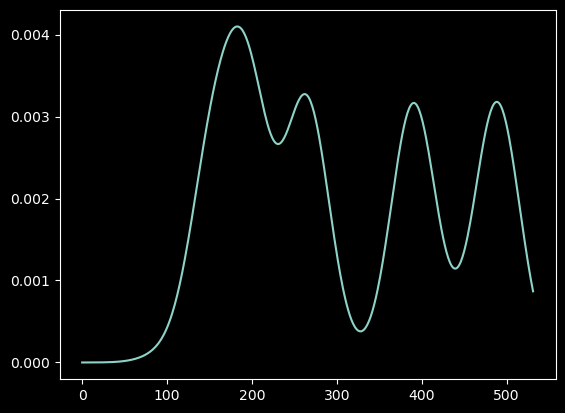

In [153]:
plt.plot(saliency_map_x)
plt.show()

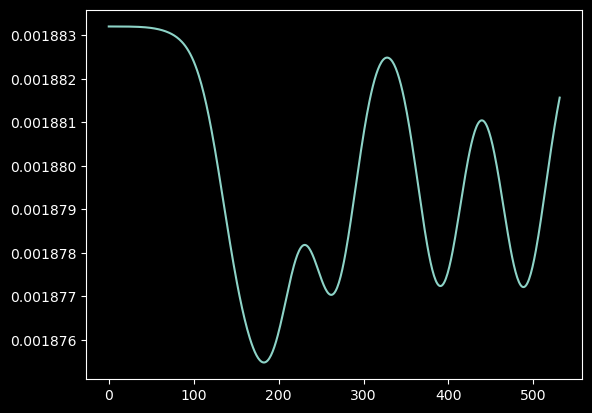

In [154]:
inv_saliency_map_x = (1 - saliency_map_x)/(1-saliency_map_x).sum()
plt.plot(inv_saliency_map_x)
plt.show()

In [37]:
convolutionGranularity = 81

In [38]:
ratio = observation_in_pixel.shape[0]/observation_in_pixel.shape[1]  # ratio of rows to values in rows
ratio

0.39285714285714285

In [47]:
number_horizontal_strides = math.ceil(np.sqrt(convolutionGranularity/ratio))
number_horizontal_strides

15

In [48]:
number_vertical_strides = math.ceil(convolutionGranularity/conv_width)
number_vertical_strides

6

In [50]:
kernel_size_x = math.ceil(np.shape(observation_in_pixel)[1] / number_horizontal_strides)
kernel_size_x

36

In [52]:
kernel_size_y = math.ceil(np.shape(observation_in_pixel)[0] / number_vertical_strides)
kernel_size_y

35

In [55]:
pooled_observation = skimage.measure.block_reduce(observation_in_pixel, (kernel_size_y, kernel_size_x), np.mean)
print(f"pooled_observation: {pooled_observation}, dimensions={len(pooled_observation[0])}*{len(pooled_observation)}")

pooled_observation: [[0.         0.         0.         0.00079365 0.         0.00079365
  0.         0.         0.         0.         0.         0.0015873
  0.         0.22857143 0.23095238]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.0015873 ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.0031746
  0.         0.         0.        ]
 [0.         0.01746032 0.34285714 0.         0.0031746  0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.00079365 0.1        0.04206349 0.41666667 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.33650794 0.00079365 0.         0.         0.00238095 0.
  0.         0.33174603 0.         0.         0.         0.
  0.         0.         0.        ]], dimensions=15*6


In [74]:
def pool_observation(observation_in_pixel, convolutionGranularity, resample=False):
    """
    Observation in pixel is pooled into an number of kernels with the number of kernels/pools given by
    the free parameter convolutionGranularity. The higher the value, the more granular is the
    representation of the visual environment. Kernels are subsequently convolved for mean pixel activation.
    """
    
    ratio = observation_in_pixel.shape[0]/observation_in_pixel.shape[1]  # ratio of rows to values in rows

    number_horizontal_strides = math.ceil(np.sqrt(convolutionGranularity/ratio))
    number_vertical_strides = math.ceil(convolutionGranularity/conv_width)

    kernel_size_x = math.ceil(np.shape(observation_in_pixel)[1] / number_horizontal_strides)
    kernel_size_y = math.ceil(np.shape(observation_in_pixel)[0] / number_vertical_strides)

    pooled_observation = skimage.measure.block_reduce(observation_in_pixel, (kernel_size_y, kernel_size_x), np.mean)
    #print(f"pooled_observation: {pooled_observation}, dimensions={len(pooled_observation[0])}*{len(pooled_observation)}")
    
    return kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides

In [23]:
###### OLD #####
def pool_observation(observation_in_pixel, convolutionGranularity, resample=False):
    """
    Observation in pixel is pooled into an number of kernels with the number of kernels/pools given by
    the free parameter convolutionGranularity. The higher the value, the more granular is the
    representation of the visual environment. Kernels are subsequently convolved for mean pixel activation.
    """
    # df = pd.DataFrame(data=observation_in_pixel[0:, 0:],
    #                  index=[i for i in range(observation_in_pixel.shape[0])],
    #                  columns=['f' + str(i) for i in range(observation_in_pixel.shape[1])])
    # df.to_csv("surfarray.csv", sep=',', index=False)
    
    # resampling? then highest granularity by default
    if resample:
        convolutionGranularity = 81
    else:
        convolutionGranularity = convolutionGranularity

    # pooling
    number_horizontal_strides = math.ceil(np.sqrt(convolutionGranularity))
    kernel_size_x = math.ceil(np.shape(observation_in_pixel)[1] / number_horizontal_strides)
    number_vertical_strides = int(convolutionGranularity / number_horizontal_strides)

    kernel_size_y = math.ceil(np.shape(observation_in_pixel)[0] / number_vertical_strides)

    pooled_observation = skimage.measure.block_reduce(observation_in_pixel, (kernel_size_y, kernel_size_x), np.mean)
    print(f"pooled_observation: {pooled_observation}, dimensions={len(pooled_observation[0])}*{len(pooled_observation)}")
    return kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides
################

In [65]:
# testing pooling
kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides = pool_observation(observation_in_pixel, 81)

pooled_observation: [[0.         0.         0.         0.00079365 0.         0.00079365
  0.         0.         0.         0.         0.         0.0015873
  0.         0.22857143 0.23095238]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.0015873 ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.0031746
  0.         0.         0.        ]
 [0.         0.01746032 0.34285714 0.         0.0031746  0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.00079365 0.1        0.04206349 0.41666667 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.33650794 0.00079365 0.         0.         0.00238095 0.
  0.         0.33174603 0.         0.         0.         0.
  0.         0.         0.        ]], dimensions=15*6


In [66]:
min_percentage_for_rejection = 0.08

In [68]:
rejected_action_possibilities = list(zip(*np.where(pooled_observation > min_percentage_for_rejection)))
rejected_action_possibilities

[(0, 13), (0, 14), (3, 2), (4, 2), (4, 4), (5, 0), (5, 7)]

In [70]:
action_field = list(zip(*np.where(pooled_observation < min_percentage_for_rejection)))
len(action_field)

83

In [72]:
pooled_observation = (pooled_observation > min_percentage_for_rejection).astype(int)
pooled_observation

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

In [93]:
def convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection, drift_situation=False, resample=False):
    """
    Every kernel of mean observation in pixel from pooled_observation is compared with
    min_percentage_for_rejection. If mean activation in kernel is higher than min_percentage_for_rejection, then
    1 is associated with kernel, reflecting the rejection of this specific possible action goal.
    """

    kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides = pool_observation(observation_in_pixel, convolutionGranularity, resample=resample)

    # identify rejected action possibilities
    rejected_action_possibilities = list(zip(*np.where(pooled_observation > min_percentage_for_rejection)))
    action_field = list(zip(*np.where(pooled_observation < min_percentage_for_rejection)))
    
    if drift_situation:
        # delete each possible in possibles that shares second digit with one in rejected and
        # the first digit of which is larger
        rejects = []
        for reject in rejected_action_possibilities:
            # rejects contains all goals on the same horizontal position as rejected_action_possibilities,
            # but vertically below rejected_action_possibilities
            rejects_ = [i for i in action_field if i[1] == reject[1] and i[0] > reject[0]]
            rejects = rejects + rejects_
            
        # only keep elements in action_field that are NOT in rejects
        action_field = [i for i in action_field if i not in rejects]
        rejected_action_possibilities = rejected_action_possibilities + rejects

    # also passing pooled observation
    pooled_observation = (pooled_observation > min_percentage_for_rejection).astype(int)
    
    #print(f"action field: {action_field}; rejected action possibilities: {rejected_action_possibilities}")

    return kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation


In [119]:
# testing convolving
kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation = convolve_observation(observation_in_pixel, 90, 0.08, False, False)
pooled_observation.shape

(6, 16)

In [59]:
###### OLD #####
def convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection, resample=False):
    """
    Every kernel of mean observation in pixel from pooled_observation is compared with
    min_percentage_for_rejection. If mean activation in kernel is higher than min_percentage_for_rejection, then
    1 is associated with kernel, reflecting the rejection of this specific possible action goal.
    """

    kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides = pool_observation(observation_in_pixel, convolutionGranularity, resample=resample)

    # identify rejected action possibilities
    # print(f'activation in cells: \n{pooled_observation}')
    rejected_action_possibilities = list(zip(*np.where(pooled_observation > min_percentage_for_rejection)))
    # print(f"rejected_action_possibilities = {rejected_action_possibilities}")
    action_field = list(zip(*np.where(pooled_observation < min_percentage_for_rejection)))
    # print(f"action_field before filter = {action_field}")
    # delete each possible in possibles that shares second digit with one in rejected and
    # the first digit of which is larger
    rejects = []
    for reject in rejected_action_possibilities:
        # rejects contains all goals on the same horizontal position as rejected_action_possibilities,
        # but vertically below rejected_action_possibilities
        rejects = [i for i in action_field if i[1] == reject[1] and i[0] > reject[0]]
        # only keep elements in action_field that are NOT in rejects
        action_field = [i for i in action_field if i not in rejects]
    # print(f"action_field: {action_field}")

    # assess time taken for conscious broadcast
    broadcast_time = np.random.uniform(200, 280, 1)
    # print(f"action field: {action_field}; rejected action possibilities: {rejected_action_possibilities}")

    # also passing pooled observation
    pooled_observation = (pooled_observation > min_percentage_for_rejection).astype(int)

    return kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, broadcast_time, rejected_action_possibilities, rejects, pooled_observation
################

In [112]:
slope

1.1004784688995215

In [122]:
vector_points

array([[10.,  0.],
       [11.,  1.],
       [12.,  2.],
       [13.,  3.],
       [14.,  4.]])

In [123]:
# check every x-position as a candidate for the vector
for x in candidate_xs:
    # get all points along the vertical vector at x
    vector_points = np.array(
        [[x + round(y * slope), y] for y in range(dy) if 0 <= x + round(y * slope) < pooled_observation.shape[1]])

In [135]:
candidate_xs

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [125]:
# as x coords; have 0 as second digit/y coords (0, 0), (1, 0), ....
# increase for stride in number_vertical_strides by 1*slope (check if its still in pool, because 1.1 may overreach)
# those are vector points
# compute distance...

In [136]:
for candidate in candidate_xs:
    vector_points = [candidate]
    for stride in range(1, number_vertical_strides+1):
        vector_point = candidate + stride*slope
        vector_points.append(vector_point)
    
    if ones_positions.size > 0 and len(vector_points) > 0:
        # compute distances from all points on the vector to all 1s
        dists = distance.cdist(vector_points, ones_positions, metric='euclidean')

        # find the closest 1 for each point on the vector
        min_dists_per_point = np.min(dists, axis=1)

        # find the worst-case (minimum) distance along the vector
        total_dist_along_vector = np.sum(min_dists_per_point)

        print(f"candidate={candidate}, cum_dist={total_dist_along_vector}")

ValueError: XA must be a 2-dimensional array.

In [137]:
candidate_array = np.array([(int(x), 0) for x in candidate_xs])
candidate_array

array([[ 0,  0],
       [ 1,  0],
       [ 2,  0],
       [ 3,  0],
       [ 4,  0],
       [ 5,  0],
       [ 6,  0],
       [ 7,  0],
       [ 8,  0],
       [ 9,  0],
       [10,  0]])

In [139]:
ones_positions

array([[ 0, 14],
       [ 0, 15],
       [ 3,  2],
       [ 4,  2],
       [ 4,  4],
       [ 5,  0],
       [ 5,  7],
       [ 5,  8]])

In [163]:
def action_selection(observation_in_pixel, convolutionGranularity, drift_direction, min_percentage_for_rejection: float):
      
    drift_prior=230
    
    dx = drift_prior*drift_direction
    dy = 210  # dy as variable that's passed; dx needs to be on pixel scale
    #dy = observation_space_size_y
    #slope = 0.45  # dx/np.shape(observation_in_pixel)[1]  # dx / dy  # expected trajectory
    slope = dx / dy  # expected trajectory
        
    kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation = convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection)
    
    # all positions within grid that are =1
    ones_positions = np.argwhere(pooled_observation == 1)

    # possible starting positions (accounting for end point remains within grid)
    if dx > 0:  # positive slope
        min_x_start, max_x_start = 0, pooled_observation.shape[1] - slope*number_vertical_strides
    else:  # negative slope
        min_x_start, max_x_start = abs(slope*number_vertical_strides), pooled_observation.shape[1] - 1

    # identifying potential starting positions
    candidate_xs = np.arange(min_x_start, max_x_start + 1)
    candidate_array = np.array([(int(x), 0) for x in candidate_xs])

    # store best x with corresponding distance score
    best_x = None  # maybe centered default position?
    expected_trajetory = None 
    max_total_dist = 0

    # check every x-position as a candidate for the vector
    for candidate in candidate_array:
        vector_points = [candidate]
        for stride in range(1, number_vertical_strides+1):
            vector_point = [candidate[0] + stride*slope, stride]
            vector_points.append(vector_point)

        if ones_positions.size > 0 and len(vector_points) > 0:
            # compute distances from all points on the vector to all 1s
            dists = distance.cdist(vector_points, ones_positions, metric='euclidean')

            # find the closest 1 for each point on the vector
            min_dists_per_point = np.min(dists, axis=1)

            # total distance along the vector
            total_dist_along_vector = np.sum(min_dists_per_point)

            #print(f"candidate={x}, vector_points={vector_points}, vector_len={len(vector_points)}")

                    # update if this x is better
            if total_dist_along_vector > max_total_dist:
                max_total_dist = total_dist_along_vector
                best_x = candidate[0]
                expected_trajetory = vector_points


    action_goal_x_coord = best_x * kernel_size_x + kernel_size_x/2 - (28/2)*drift_direction

    return best_x, expected_trajetory, action_goal_x_coord   

In [164]:
best_x, expected_trajetory, action_goal_x_coord = action_selection(observation_in_pixel, convolutionGranularity=90, drift_direction=1, min_percentage_for_rejection=0.08)

In [117]:
###### OLD #####
def action_selection(observation_in_pixel, convolutionGranularity, drift_direction, min_percentage_for_rejection: float):
    
    drift_prior=230
    
    dx = drift_prior*drift_direction
    dy = 210  # dy as variable that's passed; dx needs to be on pixel scale
    #dy = observation_space_size_y
    #slope = 0.45  # dx/np.shape(observation_in_pixel)[1]  # dx / dy  # expected trajectory
    slope = dx / dy  # expected trajectory
        
    kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation = convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection)

    # just for a quick switch between pixel map and pooled observation
    #pooled_observation = observation_in_pixel

    # all positions within grid that are =1
    ones_positions = np.argwhere(pooled_observation == 1)

    #print(f"slope:{slope}; kernel:{kernel_size_y}, {kernel_size_x}, dimensions:{np.shape(pooled_observation)}")

    # possible starting positions (accounting for end point remains within grid)
    if dx > 0:  # Positive slope
        min_x_start, max_x_start = 0, pooled_observation.shape[1] - slope*number_vertical_strides
    else:  # Negative slope
        min_x_start, max_x_start = abs(slope*number_vertical_strides), pooled_observation.shape[1] - 1
        
    # identifying potential starting positions
    candidate_xs = np.arange(min_x_start, max_x_start + 1)
    #print(f"candidates: {candidate_xs}")

    # store best x with corresponding distance score
    best_x = None  # maybe centered default position?
    max_total_dist = 0

    # check every x-position as a candidate for the vector
    for x in candidate_xs:
        # get all points along the vertical vector at x
        vector_points = np.array(
            [[x + round(y * slope), y] for y in range(dy) if 0 <= x + round(y * slope) < pooled_observation.shape[1]])
        
        print(f"candidate={x}, vector_points={vector_points}, vector_len={len(vector_points)}")
        
        if ones_positions.size > 0 and len(vector_points) > 0:
            # compute distances from all points on the vector to all 1s
            dists = distance.cdist(vector_points, ones_positions, metric='euclidean')

            # find the closest 1 for each point on the vector
            min_dists_per_point = np.min(dists, axis=1)

            # find the worst-case (minimum) distance along the vector
            total_dist_along_vector = np.sum(min_dists_per_point)
            
            print(f"candidate={x}, cum_dist={total_dist_along_vector}")
            print(f"")
            
            # update if this x is better
            if total_dist_along_vector > max_total_dist:
                max_total_dist = total_dist_along_vector
                best_x = x
    
    action_goal_x_coord = best_x * kernel_size_x + kernel_size_x/2 - (28/2)*drift_direction
    print(f"best x={best_x}; x coord={action_goal_x_coord}")
    
    
    ##################################################################
    # plotting
    # store where there is populated space, meaning there are obstacles
    populated_space_zero_coords = np.argwhere(observation_in_pixel == 1)
    populated_space_x_coords = populated_space_zero_coords[:, 1]
    populated_space_y_coords = populated_space_zero_coords[:, 0]
    populated_space_activations = pd.DataFrame({'x_coords': populated_space_x_coords,
                                                'y_coords': populated_space_y_coords})

    # Plotting action field
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))

    plt.style.use("dark_background")

    ax = sns.jointplot(data=populated_space_activations, x="x_coords", y="y_coords", color="w", space=0)

    for horizontal_stride in range(1, number_horizontal_strides+1):
        ax.ax_joint.axvline(kernel_size_x * horizontal_stride, c="r")

    for vertical_stride in range(1, number_vertical_strides+1):
        ax.ax_joint.axhline(kernel_size_y * vertical_stride, c="r")
    
    print(f"HIER: {number_horizontal_strides, kernel_size_x, number_vertical_strides, kernel_size_y}")
    
    # mark rejected
    rejected = rejected_action_possibilities
    if rejected is not None:
        rejected = [(x * kernel_size_x,
                     y * kernel_size_y)
                    for y, x in rejected]

        x_val = [x[0] for x in rejected]
        y_val = [y[1] for y in rejected]
        # print(x_val, y_val)

        for x_coord, y_coord in zip(x_val, y_val):
            rect = patches.Rectangle((x_coord, y_coord), kernel_size_x, kernel_size_y, linewidth=1, edgecolor='r',
                                     facecolor='r', alpha=0.4)
            ax.ax_joint.add_patch(rect)

    # draw expected trajectory
    #ax.ax_joint.plot([action_goal_x_coord, 0], [action_goal_x_coord+slope*dy, number_vertical_strides*kernel_size_y], marker='o', c="green")
    #ax.ax_joint.axvline(action_goal_x_coord, c="green")
    ax.ax_joint.axvline(action_goal_x_coord, c="blue")
    ax.ax_joint.axvline(action_goal_x_coord+(slope*dy), c="green")
    #ax.ax_joint.plot([0, 0], [532, 200], marker='o', c="green")

    ax.ax_joint.get_xaxis().set_visible(False)
    ax.ax_joint.get_yaxis().set_visible(False)

    ax.ax_marg_x.set_xlim(0, observation_in_pixel.shape[1])
    ax.ax_marg_y.set_ylim(0, observation_in_pixel.shape[0])

    ax.fig.axes[0].invert_yaxis()
    ##################################################################
    
    return best_x, action_goal_x_coord
################

In [152]:
best_x, action_goal_x_coord = action_selection(observation_in_pixel, convolutionGranularity=90, drift_direction=1, min_percentage_for_rejection=0.08)

Text(578.0, 209, 'Anticipated End Point')

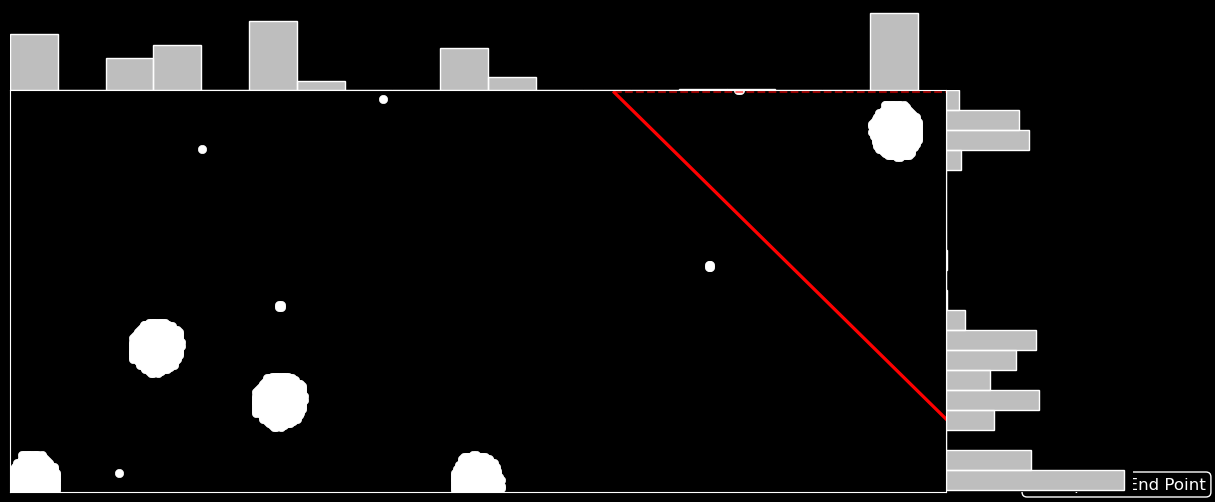

In [165]:
# store where there is populated space, meaning there are obstacles
populated_space_zero_coords = np.argwhere(observation_in_pixel == 1)
populated_space_x_coords = populated_space_zero_coords[:, 1]
populated_space_y_coords = populated_space_zero_coords[:, 0]
populated_space_activations = pd.DataFrame({'x_coords': populated_space_x_coords, 
                                            'y_coords': populated_space_y_coords})

#fig, ax = plt.subplots(1, 1, figsize=(26, 11))

plt.style.use("dark_background")

ax = sns.jointplot(data=populated_space_activations, x="x_coords", y="y_coords", color="w", space=0)
ax.fig.set_size_inches((13, 5.5))

ax.ax_marg_x.set_xlim(0, observation_in_pixel.shape[1])
ax.ax_marg_y.set_ylim(0, observation_in_pixel.shape[0])

ax.fig.axes[0].invert_yaxis()
ax.set_axis_labels('', '', fontsize=16) # don't show axis labels

for ax_i in [ax.ax_joint, ax.ax_marg_x, ax.ax_marg_y]:
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_xticklabels([])
    ax_i.set_yticklabels([])
    
drift_direction = 1
drift_prior=230
    
dx = drift_prior*drift_direction
dy = observation_in_pixel.shape[0]

slope = dx/dy

##################################################################
# vector
x_start, y_start = action_goal_x_coord, 1
x_end, y_end = action_goal_x_coord+drift_prior*drift_direction, dy

ax.ax_joint.arrow(x_start, y_start, x_end - x_start-10, y_end - y_start-10, width=1, 
                  head_width=10, head_length=10, 
                  fc='red', ec='red')

# draw vector components
ax.ax_joint.hlines(y=y_start, xmin=x_start, xmax=x_end, color='red', linestyle='dashed', alpha=0.6)
ax.ax_joint.vlines(x=x_end, ymin=y_start, ymax=y_end, color='red', linestyle='dashed', alpha=0.6)

# text components
ax.ax_joint.text(x_end+5, y_end, "Anticipated End Point", 
                 fontsize=12, color='white', ha='left', va='bottom',
                 bbox=dict(facecolor='black', edgecolor='white', boxstyle='round,pad=0.3'))

##################################################################

# point of lowest density
#ax.ax_joint.scatter(x_min_index, y_min_index, color='lime', s=100)

# Action selection functions

In [213]:
kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides = pool_observation(observation_in_pixel, 90)
kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides

(34,
 35,
 array([[0.        , 0.        , 0.00756303, 0.        , 0.00084034,
         0.41176471, 0.07394958, 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.00084034,
         0.        ],
        [0.        , 0.        , 0.        , 0.00756303, 0.        ,
         0.00252101, 0.00756303, 0.37647059, 0.11176471, 0.        ,
         0.        , 0.49159664, 0.        , 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.00756303, 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.37815126,
         0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
     

In [212]:
def pool_observation(observation_in_pixel, convolutionGranularity, resample=False):
    """
    Observation in pixel is pooled into an number of kernels with the number of kernels/pools given by
    the free parameter convolutionGranularity. The higher the value, the more granular is the
    representation of the visual environment. Kernels are subsequently convolved for mean pixel activation.
    """
    
    ratio = observation_in_pixel.shape[0]/observation_in_pixel.shape[1]  # ratio of rows to values in rows

    number_horizontal_strides = math.ceil(np.sqrt(convolutionGranularity/ratio))
    number_vertical_strides = math.ceil(convolutionGranularity/number_horizontal_strides)

    kernel_size_x = math.ceil(np.shape(observation_in_pixel)[1] / number_horizontal_strides)
    kernel_size_y = math.ceil(np.shape(observation_in_pixel)[0] / number_vertical_strides)

    pooled_observation = skimage.measure.block_reduce(observation_in_pixel, (kernel_size_y, kernel_size_x), np.mean)
    #print(f"pooled_observation: {pooled_observation}, dimensions={len(pooled_observation[0])}*{len(pooled_observation)}")
    
    return kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides

In [7]:
def convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection, drift_situation=False, resample=False):
    """
    Every kernel of mean observation in pixel from pooled_observation is compared with
    min_percentage_for_rejection. If mean activation in kernel is higher than min_percentage_for_rejection, then
    1 is associated with kernel, reflecting the rejection of this specific possible action goal.
    """

    kernel_size_x, kernel_size_y, pooled_observation, number_horizontal_strides, number_vertical_strides = pool_observation(observation_in_pixel, convolutionGranularity, resample=resample)

    # identify rejected action possibilities
    rejected_action_possibilities = list(zip(*np.where(pooled_observation > min_percentage_for_rejection)))
    action_field = list(zip(*np.where(pooled_observation < min_percentage_for_rejection)))
    
    if drift_situation:
        # delete each possible in possibles that shares second digit with one in rejected and
        # the first digit of which is larger
        rejects = []
        for reject in rejected_action_possibilities:
            # rejects contains all goals on the same horizontal position as rejected_action_possibilities,
            # but vertically below rejected_action_possibilities
            rejects_ = [i for i in action_field if i[1] == reject[1] and i[0] > reject[0]]
            rejects = rejects + rejects_
            
        # only keep elements in action_field that are NOT in rejects
        action_field = [i for i in action_field if i not in rejects]
        rejected_action_possibilities = rejected_action_possibilities + rejects

    # also passing pooled observation
    pooled_observation = (pooled_observation > min_percentage_for_rejection).astype(int)
    
    #print(f"action field: {action_field}; rejected action possibilities: {rejected_action_possibilities}")

    return kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation


In [214]:
def action_selection(observation_in_pixel, convolutionGranularity, drift_direction, min_percentage_for_rejection: float):
      
    drift_prior=219
    
    dx = drift_prior*drift_direction
    dy = 210  # dy as variable that's passed; dx needs to be on pixel scale
    #dy = observation_space_size_y
    slope = dx / dy  # expected trajectory
        
    kernel_size_x, kernel_size_y, action_field, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities, pooled_observation = convolve_observation(observation_in_pixel, convolutionGranularity, min_percentage_for_rejection)
    
    # all positions within grid that are =1
    ones_positions = np.argwhere(pooled_observation == 1)
    #ones_positions = np.argwhere(observation_in_pixel == 1)
    #print(ones_positions)

    # possible starting positions (accounting for end point remains within grid)
    #if dx > 0:  # positive slope
    #    min_x_start, max_x_start = 0, pooled_observation.shape[1] - slope*number_vertical_strides
    #else:  # negative slope
    #    min_x_start, max_x_start = abs(slope*number_vertical_strides), pooled_observation.shape[1] - 1
    
    
    if dx > 0:  # positive slope
        min_x_start, max_x_start = 0, pooled_observation.shape[1] - abs(slope*observation_in_pixel.shape[0]/kernel_size_x)
    else:  # negative slope
        min_x_start, max_x_start = abs(slope*observation_in_pixel.shape[0]/kernel_size_x), pooled_observation.shape[1] - 1
    
    
    # pixels
    #if dx > 0:  # positive slope
    #    min_x_start, max_x_start = 0, observation_in_pixel.shape[1] - slope*observation_in_pixel.shape[0]
    #else:  # negative slope
    #    min_x_start, max_x_start = abs(slope*observation_in_pixel.shape[0]), observation_in_pixel.shape[1] - 1   
        
    #print(min_x_start, max_x_start)


    # identifying potential starting positions
    candidate_xs = np.arange(min_x_start, max_x_start + 1)
    candidate_array = np.array([(0, int(x)) for x in candidate_xs])

    # store best x with corresponding distance score
    best_x = None  # maybe centered default position?
    expected_trajectory = None 
    max_total_dist = 0

    # check every x-position as a candidate for the vector
    for candidate in candidate_array:
        vector_points = [candidate]
        for stride in range(1, number_vertical_strides+1):
        #for stride in range(1, observation_in_pixel.shape[1]+1):
            vector_point = [stride, candidate[0] + stride * slope]
            vector_points.append(vector_point)
        
        min_dists_per_point = []
        if ones_positions.size > 0 and len(vector_points) > 0:
            for vector_point in vector_points:
                
                # find populated pools on the same vertical position
                potential_collisions = ones_positions[ones_positions[:, 0] == vector_point[0], 1]
                print(potential_collisions)
                
                # compute minimum distance to either populated pool or to edge of observation space
                if potential_collisions.size > 0:
                    min_dist = np.min(np.abs(potential_collisions - vector_point[1]))
                else:
                    min_dist = min(abs(vector_point[1] - 0), abs(vector_point[1] - pooled_observation.shape[1]))
                min_dists_per_point.append(min_dist)
            
            # compute distances from all points on the vector to closest 1
            #dists = distance.cdist(vector_points, ones_positions, metric='euclidean')  # cityblock
            #print(f"DISTS: {dists}")

            # find the closest 1 for each point on the vector
            #min_dists_per_point = np.min(dists, axis=1)
            #print(f"MIN DISTS: {min_dists_per_point}")

            # total distance along the vector
            total_dist_along_vector = np.sum(min_dists_per_point)
            #print(f"TOTAL DIST: {total_dist_along_vector}; dists: {min_dists_per_point}")

            #print(f"candidate={candidate}, vector_points={vector_points}, vector_len={len(vector_points)}, total_distance={total_dist_along_vector}")

            # update if this x is better
            if total_dist_along_vector > max_total_dist:
                max_total_dist = total_dist_along_vector
                best_x = candidate[0]
                expected_trajectory = vector_points


    #action_goal_x_coord = best_x * kernel_size_x + kernel_size_x/2 - (28/2)*drift_direction

    return best_x, expected_trajectory, kernel_size_x, kernel_size_y, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities   

In [215]:
best_x, expected_trajectory, kernel_size_x, kernel_size_y, number_horizontal_strides, number_vertical_strides, rejected_action_possibilities = action_selection(observation_in_pixel, convolutionGranularity=90, drift_direction=1, min_percentage_for_rejection=0.08)

best_x

[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5]
[ 7  8 11]
[]
[14]
[14]
[4]
[]


0

In [187]:
scaled_expected_trajectory = [np.array([x * kernel_size_x - kernel_size_x/2, y * kernel_size_y]) for x, y in expected_trajectory]

In [188]:
expected_trajectory

[array([0, 0]),
 [1, 1.042857142857143],
 [2, 2.085714285714286],
 [3, 3.128571428571429],
 [4, 4.171428571428572],
 [5, 5.214285714285714],
 [6, 6.257142857142858]]

[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]
[5 6]
[ 7  8 11]
[]
[14]
[14]
[4]
[]


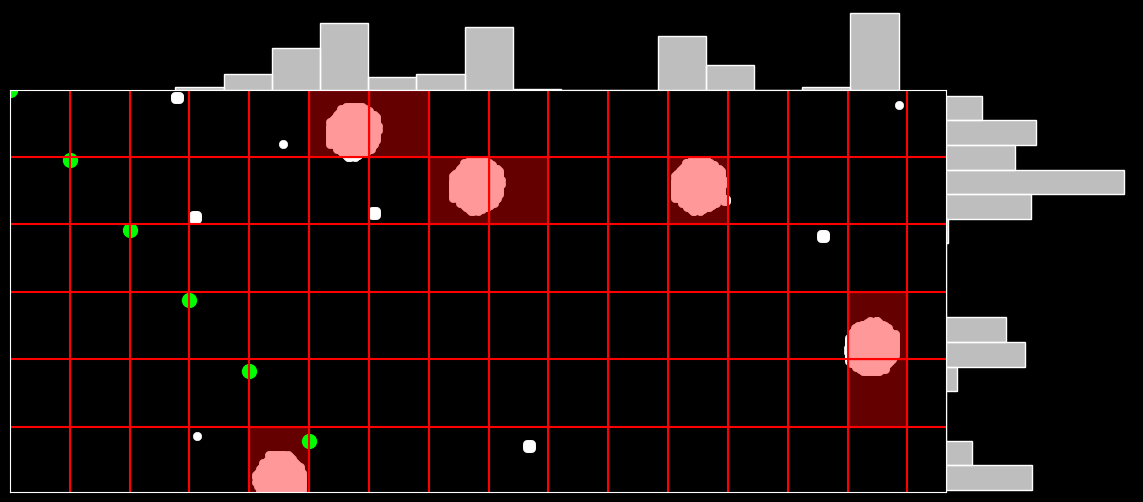

In [186]:
best_x, expected_trajectory, kernel_size_x, kernel_size_y, number_horizontal_strides, number_vertical_strides, rejected = action_selection(observation_in_pixel, convolutionGranularity=90, drift_direction=1, min_percentage_for_rejection=0.07)

scaled_expected_trajectory = [np.array([x * kernel_size_x, y * kernel_size_y]) for x, y in expected_trajectory]


# store where there is populated space, meaning there are obstacles
populated_space_zero_coords = np.argwhere(observation_in_pixel == 1)
populated_space_x_coords = populated_space_zero_coords[:, 1]
populated_space_y_coords = populated_space_zero_coords[:, 0]
populated_space_activations = pd.DataFrame({'x_coords': populated_space_x_coords, 
                                            'y_coords': populated_space_y_coords})

#fig, ax = plt.subplots(1, 1, figsize=(26, 11))

plt.style.use("dark_background")

ax = sns.jointplot(data=populated_space_activations, x="x_coords", y="y_coords", color="w", space=0)
ax.fig.set_size_inches((13, 5.5))

for horizontal_stride in range(1, number_horizontal_strides+1):
    ax.ax_joint.axvline(kernel_size_x * horizontal_stride, c="r")

for vertical_stride in range(1, number_vertical_strides+1):
    ax.ax_joint.axhline(kernel_size_y * vertical_stride, c="r")

# mark rejected
if rejected is not None:
    rejected = [(x * kernel_size_x,
                 y * kernel_size_y)
                for y, x in rejected]

    x_val = [x[0] for x in rejected]
    y_val = [y[1] for y in rejected]
    # print(x_val, y_val)

    for x_coord, y_coord in zip(x_val, y_val):
        rect = patches.Rectangle((x_coord, y_coord), kernel_size_x, kernel_size_y, linewidth=1, edgecolor='r',
                                 facecolor='r', alpha=0.4)
        ax.ax_joint.add_patch(rect)    

ax.ax_marg_x.set_xlim(0, observation_in_pixel.shape[1])
ax.ax_marg_y.set_ylim(0, observation_in_pixel.shape[0])

ax.fig.axes[0].invert_yaxis()
ax.set_axis_labels('', '', fontsize=16) # don't show axis labels

for ax_i in [ax.ax_joint, ax.ax_marg_x, ax.ax_marg_y]:
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_xticklabels([])
    ax_i.set_yticklabels([])
    
#drift_direction = 1
#drift_prior=219
    
#dx = drift_prior*drift_direction
#dy = observation_in_pixel.shape[0]

#slope = dx/dy

##################################################################
# vector
#x_start, y_start = action_goal_x_coord, 1
#x_end, y_end = action_goal_x_coord+drift_prior*drift_direction, dy

#ax.ax_joint.arrow(x_start, y_start, x_end - x_start-10, y_end - y_start-10, width=1, 
#                  head_width=10, head_length=10, 
#                  fc='red', ec='red')

# draw vector components
#ax.ax_joint.hlines(y=y_start, xmin=x_start, xmax=x_end, color='red', linestyle='dashed', alpha=0.6)
#ax.ax_joint.vlines(x=x_end, ymin=y_start, ymax=y_end, color='red', linestyle='dashed', alpha=0.6)

# text components
#ax.ax_joint.text(x_end+5, y_end, "Anticipated End Point", 
#                 fontsize=12, color='white', ha='left', va='bottom',
#                 bbox=dict(facecolor='black', edgecolor='white', boxstyle='round,pad=0.3'))



##################################################################

for point in scaled_expected_trajectory:
#for point in expected_trajectory:
    ax.ax_joint.scatter(point[0], point[1], color='lime', s=100)

In [190]:
observation_in_pixel.shape

(209, 532)

In [193]:
230/kernel_size_x

6.764705882352941

In [194]:
pooled_observation.shape[1]

NameError: name 'pooled_observation' is not defined